## 7.5 LSTM

RNN은 결정적인 단점이 있다. 기울기가 1보다 작은 값이 계속 곱해지기 때문에 기울기가 사라지는 기울기 소멸 문제가 발생한다. 이를 해결하기 위해 LSTM이나 GRU 같은 확장된 RNN 방식을 사용한다.

### 7.5.1 LSTM 구조

#### LSTM 순전파
LSTM은 기울기 소멸 문제를 해결하기 위해 망각 게이트, 입력 게이트, 출력 게이트라는 새로운 요소를 은닉층의 각 뉴런에 추가했다.


##### 망각 게이트
망각 게이트는 과거 정보를 어느 정도 기억할지 결정한다. 과거 정보와 현재 데이터를 입력받아 시그모이드를 취한 후 그 값을 과거 정보에 곱해 준다. 따라서 시그모이드의 출력이 0이면 과거 정보는 버리고, 1이면 과거 정보는 온전히 보존한다.
0과 1 사이의 출력 값을 가지는 h_t-1과 x_t를 입력 값으로 받는다. 이때 x_t는 새로운 입력 값이고 h_t-1은 이전 은닉층에서 입력되는 값이다 즉, h_t-1과 x_t를 이용하여 이전 상태 정보를 현재 메모리에 반영할지 결정하는 역할을 한다.
- 계산한 값이 1이면 바로 직전의 정보를 메모리에 유지
- 계산한 값이 0이면 초기화
망각 게이트 대한 수식은 다음과 같다.
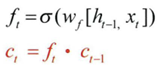

그림으로는 다음과 같이 표현할 수 있다.
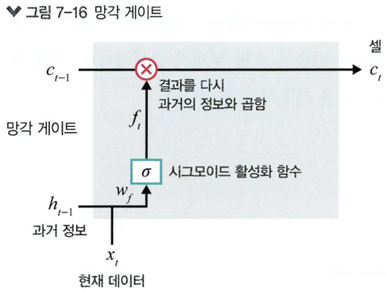


##### 입력 게이트
입력 게이트는 현재 정보를 기억하기 위해 만들어졌다. 과거 정보와 현재 데이터를 입력받아 시그모이드와 하이퍼볼릭 탄젠트 함수를 기반으로 현재 정보에 대한 보존량을 결정한다. 즉, 현재 메모리에 새로운 정보를 반영할지 결정하는 역할을 한다.
- 계산한 값이 1이면 입력 x_t가 들어올 수 있도록 허용(open)
- 계산한 값이 0이라면 차단
이것을 수식으로 정리하면 다음과 같다.
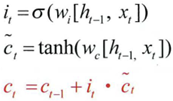
그림으로는 다음과 같이 표현할 수 있다.

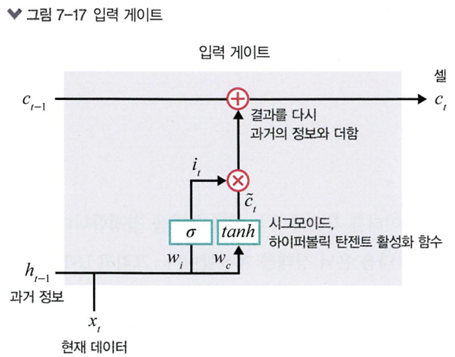


##### 셀
각 단계에 대한 은닉 노드를 메모리 셀이라고 한다. 총합을 사용하여 셀 값을 반영하며, 이것으로 기울기 소멸 문제가 해결된다. 셀을 업데이트하는 방법은 다음과 같다. 망각 게이트와 입력 게이트의 이전 단계 셀 정보를 계산하여 현재 단계의 셀 상태를 업데이트한다. 다음은 셀에 대한 수식이다.
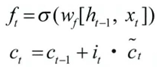
그림으로는 다음과 같이 표현할 수 있다.
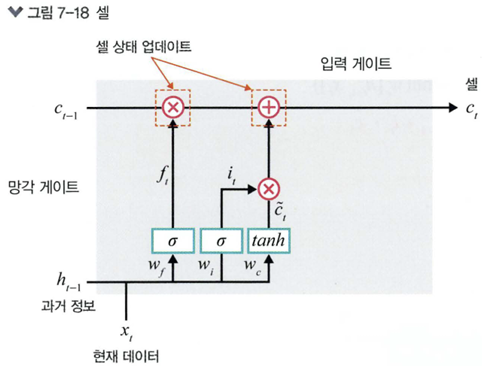

##### 출력 게이트
출력 게이트는 과거 정보와 현재 데이터를 사용하여 뉴런의 출력을 결정한다. 이전 은닉 상태와 t번째 입력을 고려해서 다음 은닉 상태를 계산한다. 그리고 LSTM에서는 이 은닉 상태가 그 시점에서의 출력이 된다. 출력 게이트는 갱신된 메모리의 출력 값을 제어하는 역할을 한다.
- 계산한 값이 1이면 의미 있는 결과로 최종 출력
- 계산한 값이 0이면 해당 연산 출력을 하지 않음
이것을 수식으로 정리하면 다음과 같다.
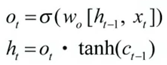
그림은 다음과 같이 표현할 수 있다.
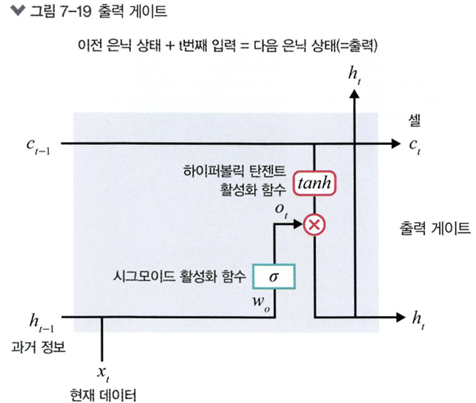

다음 그림은 망각 게이트, 입력 게이트, 출력 게이트를 모두 표현한 것이다.
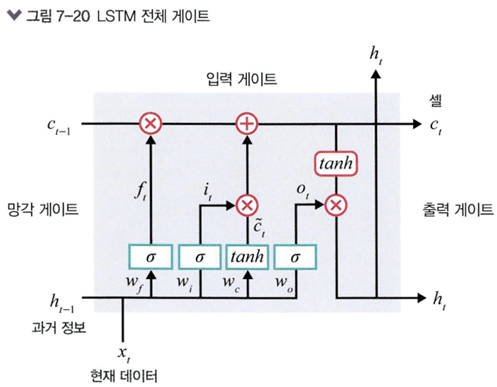

#### LSTM 역전파
LSTM은 셀을 통해서 역전파를 수행하기 때문에 중단 없는 기울기라고도 한다. 즉, 다음 그림과 같이 최종 오차는 모든 노드에 전파되는데, 이때 셀을 통해서 중단 없이 전파된다.

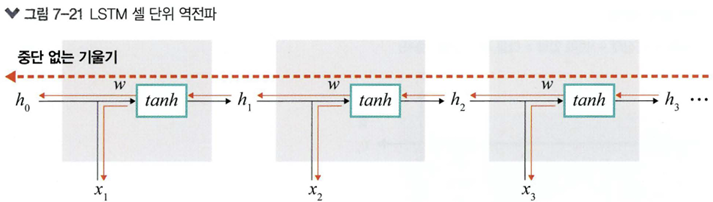
다음은 역전파를 수행하기 위한 공식이다.
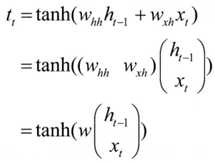
이때 주의해야 할 것은 셀 단위로 오차가 전파된다고 해서 입력 방향으로 오차가 전파되지 않는 것은 아니다. 다음 그림과 같이 셀 내부적으로는 오차가 입력(x_t)으로 전파된다는 것도 잊지 말아야 한다.
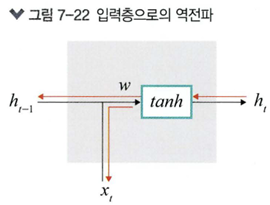

## 7.5.1 LSTM 셀 구현
지금까지 RNN을 살펴보았다면 이제 LSTM 셀과 LSTM 계층을 살펴본다. 이번 예제에서 사용할 데이터셋은 MNIST이다.MNIST는 인공지능 연구의 권위자 얀 르쿤 교수가 만든 데이터셋으로 훈련 데이터셋 6만 개와 검증 데이터셋 1만 개로 구성되어 있다. MNIST는 손으로 쓴 숫자 이미지(0에서 9까지 값을 갖는 고정 크기 이미지(28X28 픽셀))들로 구성되어 있다. 먼저 필요한 라이브러리를 호출합니다.

In [1]:
import torch
import torch .nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as dataset
from torch .autograd import Variable
from torch . nn import Parameter # 파라미터 목록을 갖고 있는 라이브러리(패키지)
from torch import Tensor
import torch.nn.functional as F
from torch.utils.data import DataLoader
import math # 수학과 관련되어 다양한 함수들과 상수들이 정의되어 있는 라이브러리

device = torch .device( 'cuda:0' if torch.cuda.is_available() else 'cpu')
cuda = True if torch.cuda.is_available() else False # GPU 사용에 필요
Tensor = torch.cuda.FloatTensor if cuda else torch.FloatTensor # GPU 사용에 필요

torch .manual_seed(125)
if torch.cuda.is_available():
  torch.cuda.manual_seed_all(125)

데이터에 대한 전처리를 한다. 평균과 표준편차에 맞게 데이터를 정규화하기 위한 코드이다.

In [2]:
import torchvision.transforms as transforms

mnist_transform = transforms .Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (1.0,)) #평균을 0.5, 표준편차를 1.0으로 데이터 정규화 (데이터 분포를 조정)
])

torchvision.datasets에서 제공하는 데이터셋 중 MNIST 데이터셋을 내려받습니다.

In [3]:
from torchvision.datasets import MNIST

from google.colab import drive
drive.mount('/content/drive')

download_root = '/content/drive/MyDrive/MNIST/MNIST_DATASET'

train_dataset = MNIST(download_root, transform=mnist_transform, train=True, download=True) #1
valid_dataset = MNIST( download_root, transform=mnist_transform, train=False, download=True)
test_dataset = MNIST( download_root, transform=mnist_transform, train=False, download=True)

Mounted at /content/drive


100%|██████████| 9.91M/9.91M [00:00<00:00, 62.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 52.2MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.6MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.4MB/s]


1. MNIST 데이터셋을 내려받기 위해 필요한 파라미터는 다음과 같습니다.

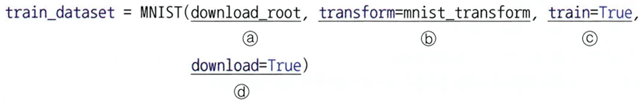

(a) 첫 번째 파라미터: MNIST를 내려받을 위치 지정

(b) transform: 앞에서 정의했던 데이터 전처리 적용

(c) train: True로 설정할 경우 훈련용 데이터셋을 가져오지만, False로 설정할 경우 테스트용 데이터셋을 가져옴

(d) download: True로 설정될 경우 내려받으려는 위치에 MNIST 파일이 없으면 내려받지만 파일이 있다면 내려받지 않음

데이터 로더를 이용하여 내려받은 MNIST 파일을 메모리로 불러온다. 단, train_loader, valid_loader, test_loader가 호출될 때 메모리로 불러온다는 점에 주의해야 한다.

In [4]:
batch_size = 64
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=True)

배치 크기 및 에포크 등 변수에 대한 값을 지정한다.

In [5]:
batch_size=100
n_iters=6000
num_epochs = n_iters / (len(train_dataset) / batch_size)
num_epochs = int(num_epochs)

LSTM 셀에 대한 네트워크를 구축한다. 모델의 전반적인 네트워크가 아닌 LSTM 셀에 집중한 네트워크이다.

In [6]:
class LSTMCell (nn . Module):
   def __init__ (self, input_size, hidden_size, bias=True):
    super(LSTMCell , self). __init__()
    self.input_size = input_size
    self.hidden_size = hidden_size
    self.bias = bias
    self.x2h = nn.Linear(input_size, 4 * hidden_size, bias=bias) #1
    self.h2h = nn. Linear( hidden_size, 4 * hidden_size, bias=bias) #1'
    self.reset_parameters()

def reset_parameters (self): # 모델의 파라미터 초기화
  std = 1.0 / math.sqrt(self.hidden_size)
  for w in self.parameters():
    w.data.uniform_(-std, std) #2

def forward(self, x, hidden):
  hx, cx = hidden
  x = x.view(-1 , x.size(1))

  gates = self.x2h(x) + self.h2h(hx ) #1"
  gates = gates. squeeze() #3
  ingate, forgetgate, cellgate, outgate = gates.chunk (4, 1) #1'''

  ingate = F.sigmoid (ingate) # 입력 게이트에 시그모이드 활성화 함수 적용
  forgetgate = F.sigmoid (forgetgate) # 망각 게이트에 시그모이드 활성화 함수 적용
  cellgate = F.tanh(cellgate) # 셀 게이트에 탄젠트 활성화 함수 적용
  outgate = F.sigmoid(outgate) # 출력 게이트에 시그모이드 활성화 함수 적용

  cy = torch.mul(cx,forgetgate) + torch.mul(ingate, cellgate) #4
  hy = torch.mul(outgate, F.tanh(cy)) #4'
  return (hy,cy)

1, 1' self.x2h = nn.Linear(input_size, 4 * hidden_size, bias=bias)와 self.h2h =
nn.Linear(hidden_size, 4 * hidden_size, bias=bias)에서 4 * hidden_size가 사용되고 있는 이유에 대해 생각해 볼 필요가 있습니다. 왜 은닉층의 뉴런/유닛에 4를 곱할까요? 그 답을 알기 위해서는 다음 그림을 먼저 이해해야 합니다.

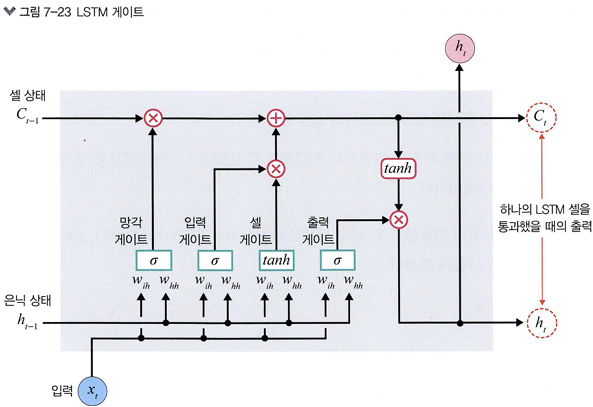

그림과 같이 LSTM에서 중요한 것은 게이트이다. 게이트는 망각, 입력, 셀, 출력으로 구성되며 이 모든 게이트는 1''처럼 구할 수 있다.

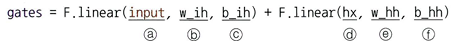

- a: 입력층으로 입력되는 훈련 데이터셋의 특성(feature)수 (칼럼 개수)
- b: 입력층과 은닉층 사이의 가중치
- c: 입력층과 은닉층 사이의 바이어스
- d: 은닉층의 뉴런/유닛 개수 (은닉층의 특성(feature) 수)
- e: 은닉층과 은닉층 사이의 가중치
- f: 은닉층과 은닉층 사이의 바이어스

이렇게 계산된 게이트(gates)는 1'''처럼 gates.chunk(4,1)에 의해 네 개로 쪼개져서 각각 망각, 입력, 셀, 출력 게이트를 의미하는 변수에 저장된다. 즉, gates가 네 개로 쪼개지는 상황이기 때문에 4가 곱해졌던 것이다. 일반적으로 바이어스도 4를 곱해 주지만 예제에서는 은닉층의 뉴런/유닛 개수만 4를 곱해 주었다. 또한, 여기에서 사용되는 torch.chunk() 사용 방법은 다음과 같다. torch.chunk는 텐서를 쪼갤 때 사용하는 함수이며 파라미터는 다음과 같다.

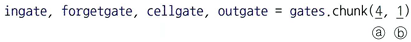

- a. 첫 번째 파라미터: 텐서를 몇 개로 쪼갤지 결정한다.
- b. 두 번째 파라미터: 어쩐 차원을 기준으로 쪼갤지를 결정한다. dim=1이므로 열 단위로 텐서를 분할하겠다는 의미이다.

2. uniform() 난수를 위해 사용한다. 난수 사용은 uniform() 외에도 randint(), random() 등이 있는데, 사용 방법은 다음과 같다.

In [8]:
from random import *
ri = randint(1, 10) # 1부터 10 사이의 임의의 정수
print(ri)

rd = random()  # 0부터 1 사이의 임의의 실수(float)
print (rd )

ui = uniform(1, 10)  # 1부터 10 사이의 임의의 실수(float)
print(ui)

rr = randrange( 1, 10, 2) # 1부터 10 사이를 2씩 건너띈 임의의 정수(예. 1,3,5,7,9)
print(rr)

3
0.10536942435724894
7.3846521176235305
5


3. torch.sqeeze()는 텐서의 차원을 줄이고자 할 때 사용한다.

In [9]:
import torch
x = torch.FloatTensor([[1], [2]]) #(2 x1) 크기의 2차원 텐서 생성
print(x)
print(x.shape)
print( '--squeeze 적용--' )
print (x. squeeze ( )) # squeeze()가 적용되어 1차원으로 축소
print(x.squeeze().shape)

tensor([[1.],
        [2.]])
torch.Size([2, 1])
--squeeze 적용--
tensor([1., 2.])
torch.Size([2])


squeeze()를 적용한 결과 (2X1) 텐서가 (2,) 크기를 갖는 1차원 벡터로 변경되었습니다.
4, 4'' 하나의 LSTM 셀을 통과하면 셀(c_t) 상태와 은닉상태(h_t)가 출력으로 주어진다. 여기에서 사용되는 torch.mul()은 텐서에 곱셈을 할 때 사용한다. 사용 방법은 다음과 같다.

In [10]:
import torch
x = torch .FloatTensor([[1], [2]]) # 임의의 텐서 생성
print(x)
print( '--mu1 적용 __ ' )
torch.mul(x, 3) #x라는 텐서의 원소에 3을 곱함

tensor([[1.],
        [2.]])
--mu1 적용 __ 


tensor([[3.],
        [6.]])

In [23]:
import torch
import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, layer_dim, output_dim):
        super(LSTMModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.layer_dim = layer_dim

        # LSTMCell은 한 층만 담당합니다. (다층은 nn.LSTM 권장)
        self.lstm = nn.LSTMCell(input_dim, hidden_dim)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # x shape: (batch_size, seq_len, input_dim)
        device = x.device
        batch_size = x.size(0)
        seq_len = x.size(1)

        # 초기 상태 설정 (batch_size, hidden_dim)
        h0 = torch.zeros(batch_size, self.hidden_dim).to(device)
        c0 = torch.zeros(batch_size, self.hidden_dim).to(device)

        hn, cn = h0, c0
        outs = []

        for seq in range(seq_len):
            # x[:, seq, :] -> (batch_size, input_dim)
            hn, cn = self.lstm(x[:, seq, :], (hn, cn))
            outs.append(hn)

        # 마지막 시점의 출력을 사용
        out = outs[-1]
        out = self.fc(out)
        return out

1. LSTM 셀은 앞에서 정의한 함수를 불러오는 부분으로 파라미터는 다음과 같다.

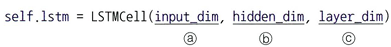

- a. input_dim: 입력에 대한 특성(feature)수(칼럼 개수)
- b. hidden_dim: 은닉층의 뉴런 개수
- c. layer_dim: 은닉층의 계층 개수

옵티마이저와 손실 함수를 지정한다.

In [24]:
input_dim = 28
hidden_dim = 128
layer_dim = 1
output_dim =10

model = LSTMModel(input_dim, hidden_dim, layer_dim, output_dim)
if torch.cuda.is_available(): # GPU 사용 유무 확인
  model.cuda()
criterion = nn.CrossEntropyLoss()
learning_rate = 0.1
optimizer = torch.optim.SGD( model.parameters() , lr=learning_rate)


훈련 데이터셋을 이용하여 모델을 학습시키고, 검증 데이터셋을 이용하여 모델 성능을 확인해본다.

In [25]:
seq_dim=28
loss_list = []
iter = 0
for epoch in range(num_epochs) :
   for i, (images ,labels) in enumerate(train_loader) :  # 훈련 데이터셋을 이용한 모델 학습
       if torch.cuda.is_available() :
           images = Variable(images.view(-1, seq_dim, input_dim).cuda())
           labels = Variable(labels.cuda())

       else :
           images = Variable(images.view(-1, seq_dim, input_dim))
           labels = Variable(labels)

       optimizer.zero_grad()
       outputs = model(images)
       loss = criterion(outputs, labels)

       if torch.cuda.is_available() :
           loss.cuda()

       loss.backward()
       optimizer.step()
       loss_list.append(loss.item())
       iter += 1


       if iter % 500 == 0 :
           correct = 0
           total = 0

           for images, labels in valid_loader :

               if torch.cuda.is_available() :
                   images = Variable(images.view(-1, seq_dim, input_dim).cuda())
               else :
                   images = Variable(images.view(-1, seq_dim, input_dim))

               outputs = model(images)
               _, predicted = torch.max(outputs.data, 1)

               total += labels.size(0)
               if torch.cuda.is_available() :
                   correct += (predicted.cpu() == labels.cpu()).sum()

               else :
                   correct += (predicted == labels).sum()

           accuracy = 100 * correct / total
           print(f'Iteration : {iter} Loss : {loss.item()} Accuracy : {accuracy}')

Iteration : 500 Loss : 2.283287763595581 Accuracy : 14.789999961853027
Iteration : 1000 Loss : 0.8219963908195496 Accuracy : 66.9000015258789
Iteration : 1500 Loss : 0.27309149503707886 Accuracy : 86.9800033569336
Iteration : 2000 Loss : 0.45624154806137085 Accuracy : 91.3499984741211
Iteration : 2500 Loss : 0.22558000683784485 Accuracy : 93.93000030517578
Iteration : 3000 Loss : 0.1352439969778061 Accuracy : 95.58999633789062
Iteration : 3500 Loss : 0.03396976366639137 Accuracy : 96.36000061035156
Iteration : 4000 Loss : 0.10755959153175354 Accuracy : 96.29000091552734
Iteration : 4500 Loss : 0.1336105465888977 Accuracy : 96.9000015258789
Iteration : 5000 Loss : 0.04372420907020569 Accuracy : 97.19000244140625
Iteration : 5500 Loss : 0.06969299167394638 Accuracy : 97.45999908447266
Iteration : 6000 Loss : 0.028126560151576996 Accuracy : 97.58000183105469
Iteration : 6500 Loss : 0.035382676869630814 Accuracy : 97.56999969482422
Iteration : 7000 Loss : 0.09925608336925507 Accuracy : 97.

현재 버전에서는 모든 텐서가 자동으로 Variable의 성질을 갖기 때문에 torch.autograd.Variable을 사용할 필요가 없지만 학습/연습 및 이전 버전에서 구현된 파이토치 코드를 이해하기 위해 사용한다. 정확도가 97%로 상당히 높은 것을 확인할 수 있다. 이제 테스트 데이터셋을 이용하여 모델 예측 성능을 살펴본다.

In [26]:
def evaluate(model, val_iter) :
    corrects, total, total_loss = 0, 0, 0
    model.eval()
    for images, labels in val_iter :
        if torch.cuda.is_available() :
            images = Variable(images.view(-1, seq_dim, input_dim).cuda())
            labels = labels.cuda()
        else :
            images = Variable(images.view(-1, seq_dim, input_dim).to(device))
            labels = labels.to(device)

        logit = model(images).to(device)
        loss = F.cross_entropy(logit, labels, reduction='sum') # 모든 오차 총합
        _, predicted = torch.max(logit.data, 1)
        total += labels.size(0)
        total_loss += loss.item()
        corrects += (predicted == labels).sum()

    avg_loss = total_loss / len(val_iter.dataset)
    avg_accuracy = corrects / total
    return avg_loss, avg_accuracy

모델 학습 및 모델 예측 관련한 코드는 비슷한 패턴으로 진행됩니다. 따라서 모델의 네트워크 및 네트워크에서 사용되는 파라미터에 집중하여 학습하면 좋다. 마지막으로 테스트 데이터셋을 이용한 모델 예측 성능을 확인해본다.

In [27]:
test_loss , test_acc = evaluate(model , test_loader)
print('Test Loss: %5.2f : Test Accuracy: %5.2f' % (test_loss, test_acc) )

Test Loss:  0.07 : Test Accuracy:  0.98


IMDB에서 MNIST로 데이터셋이 바뀌기는 했지만 98%로 성능이 매우 좋다. IMDB는 사전에 전처리가 되지 않은 데이터셋이고, MNIST는 사전에 전처리가 된 상태의 데이터셋이기 때문에 정확도 측면에서 차이가 날 수 있다. 이와 같이 사전에 전처리가 되지 않은 데이터셋의 경우 정확도를 높이기 위해 은닉층의 개수(혹은 뉴런의 개수) 및 하이퍼파라미터 수정 등이 필요하다.

### 7.5.3 LSTM 계층 구현
LSTM 계층에 대한 예제 데이터셋은 스타벅스 주가 데이터셋을 사용한다. 또한, 예제를 통해 확인하고자 하는 것은 모델이 얼마나 주가 예측을 잘 하는지에 대해 알아보는 것이다.

In [28]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torch .autograd import Variable
from tqdm import tqdm_notebook
from sklearn .preprocessing import StandardScaler, MinMaxScaler
from sklearn .model_selection import train_test_split

device = torch .device( 'cuda:0'  if torch .cuda .is_available() else 'cpu' )

이번 예제에서 사용할 데이터셋은 스타벅스 주가이다.

In [29]:
data = pd.read_csv( '/content/drive/MyDrive/SBUX.csv' )
print(data .dtypes)

Date          object
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object


데이터셋에 포함된 'Date' 칼럼을 인덱스로 사용하도록 한다. 이번 예제에서 사용할 데이터들은 숫자이기 때문에 임베딩이 필요하지 않지만 단어들로 구성도니 데이터셋은 임베딩 과정을 거쳐야 한다. 이때 날짜 칼럼은 임베딩 처리가 어려운 경우가 많은데, 날짜 칼럼을 인덱스로 처리하면 편리하다.

In [30]:
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)

'Volume' 칼럼은 정수(int)라는 데이터 형식을 갖는데, 이것을 실수(float)로 변경한다. 여기도 마찬가지로 데이터 형식을 실수로 맞추고 시작하면 추후 데이터를 센서로 변환할 때 편리하다.

In [31]:
data['Volume'] = data['Volume'].astype(float)

데이터에 대한 전처리가 완료되었다면 데이터셋을 훈련과 정답(레이블)로 분리하고 그 결과를 출력한다.

In [32]:
X = data.iloc[:, :-1]  # 마지막 칼럼을 제외한 모든 칼럼을 x로 사용
y = data.iloc[:, 5:6]  # 마지막 Volume을 레이블로 사용
print(X)
print(y)

                  Open        High         Low       Close   Adj Close
Date                                                                  
2019-12-11   86.260002   86.870003   85.849998   86.589996   84.145752
2019-12-12   88.000000   88.889999   87.540001   88.209999   85.720032
2019-12-13   88.019997   88.790001   87.580002   88.669998   86.167046
2019-12-16   89.139999   89.300003   88.430000   88.779999   86.273941
2019-12-17   88.870003   88.970001   87.470001   88.129997   85.642288
...                ...         ...         ...         ...         ...
2020-12-04  101.349998  102.940002  101.070000  102.279999  101.442787
2020-12-07  102.010002  102.220001  100.690002  101.410004  100.579918
2020-12-08  100.370003  101.570000  100.010002  101.209999  100.381554
2020-12-09  101.940002  102.209999  100.099998  100.400002   99.578186
2020-12-10  103.510002  106.089996  102.750000  105.389999  104.527336

[253 rows x 5 columns]
                Volume
Date                  
2019-12

데이터셋에서 데이터 간의 분포가 다르게 나타나고 있다. 분포를 고르게 맞추기 위한 과정이 필요한데 MinMaxScaler()와 StandardScaler()를 사용하여 분산을 조정해본다.

In [33]:
ms = MinMaxScaler()  # 데이터의 모든 값이 0~1 사이에 존재하도록 분산 조정
ss = StandardScaler()  # 데이터가 평균 0, 분산 1이 되도록 분산 조정

X_ss = ss.fit_transform(X)
y_ms = ms.fit_transform(y)

X_train = X_ss[:200, :]
X_test = X_ss[200:, :]

y_train = y_ms[:200, :]
y_test = y_ms[200:, :]

print("Training Shape" , X_train.shape, y_train.shape)
print("Testing Shape", X_test.shape, y_test.shape)

Training Shape (200, 5) (200, 1)
Testing Shape (53, 5) (53, 1)


훈련 데이터셋(X_train)은 200개의 데이터와 다섯 개의 칼럼으로 구성되어 있으며， 테스트 데이터셋(y_test)은 53개의 데이터와 한 개의 칼럼으로 구성되어 있는 것을 확인할 수 있습니다.모든 데이터셋은 그 자체로 네트워크에 보낼 수 없습니다. 네트워크에서 정의된 형태 및 크기에 따라 데이터셋 크기를 조정한 후 네트워크로 보내야 합니다.

In [34]:
X_train_tensors = Variable(torch.Tensor(X_train))# Variable로 감싸진 텐서는.backward()가 호출될 때 자동으로 기울기가 계산됨
X_test_tensors = Variable(torch.Tensor(X_test))

y_train_tensors = Variable(torch.Tensor(y_train))
y_test_tensors = Variable(torch.Tensor(y_test))

X_train_tensors_f = torch.reshape(X_train_tensors, (X_train_tensors.shape[0],
                                                    1, X_train_tensors.shape[1]))
X_test_tensors_f = torch.reshape(X_test_tensors, (X_test_tensors.shape[0],
                                                  1, X_test_tensors.shape[1]))

print('Training Shape', X_train_tensors_f.shape, y_train_tensors.shape)
print('Testing Shape', X_test_tensors_f.shape, y_test_tensors.shape)

Training Shape torch.Size([200, 1, 5]) torch.Size([200, 1])
Testing Shape torch.Size([53, 1, 5]) torch.Size([53, 1])


1 torch.reshape은 텐서의 형태를 바꿀 때 사용하며, 훈련 데이터셋(X_train_tensors)의 형태(200,5)를 (200,1,5)로 변경하겠다는 의미이다. 이와 같이 데이터셋의 형태를 변경하는 이유는 LSTM 네트워크의 입력 형태를 맞추기 위함이다. 이제 LSTM 모델의 네트워크를 구성해본다.

In [35]:
class LSTM(nn.Module) :
    def __init__(self, num_classes, input_size, hidden_size, num_layers, seq_length) :
        super(LSTM, self).__init__()
        self.num_classes = num_classes
        self.num_layers = num_layers # LSTM 계층 개수
        self.input_size = input_size # 입력 크기
        self.hidden_size = hidden_size # 은닉층 뉴런 개수
        self.seq_length = seq_length # 시퀀스 길이

        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
                            num_layers=num_layers, batch_first=True) # LSTM 계층
        self.fc_1 = nn.Linear(hidden_size, 128) # 완전 연결층
        self.fc = nn.Linear(128, num_classes) # 출력층
        self.relu = nn.ReLU()

    def forward(self, x) :
        h_0 = Variable(torch.zeros(self.num_layers, x.size(0), self.hidden_size)) # 은닉상태 0으로 초기화
        c_0 = Variable(torch.zeros(self.num_layers, x.size(0), self.hidden_size)) # 셀 상태 0으로 초기화
        output, (hn, cn) = self.lstm(x, (h_0, c_0)) # LSTM 계층에 은닉, 셀 상태 적용
        hn = hn.view(-1, self.hidden_size) # 데이터 형태 조정
        out = self.relu(hn)
        out = self.fc_1(out)
        out = self.relu(out)
        out = self.fc(out)
        return out

모델 학습에 필요한 변수 값들을 설정한다.

In [36]:
num_epochs = 1000
lr = 0.0001

input_size=5
hidden_size=2
num_layers=1

num_classes=1
model = LSTM(num_classes, input_size, hidden_size, num_layers, X_train_tensors_f.shape[1])

criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

이제 모델을 학습시킨다.

In [37]:
for epoch in range(num_epochs) :
    outputs = model.forward(X_train_tensors_f) # 전방향 학습
    optimizer.zero_grad()
    loss = criterion(outputs, y_train_tensors)
    loss.backward()

    optimizer.step()
    if epoch % 100 == 0 :
        print("Epoch: %d, loss: %1.5f" % (epoch, loss.item()))

Epoch: 0, loss: 0.04994
Epoch: 100, loss: 0.01867
Epoch: 200, loss: 0.01783
Epoch: 300, loss: 0.01643
Epoch: 400, loss: 0.01432
Epoch: 500, loss: 0.01179
Epoch: 600, loss: 0.01138
Epoch: 700, loss: 0.01179
Epoch: 800, loss: 0.01117
Epoch: 900, loss: 0.01096


오차 위주로 출력했기 때문에 실제로 얼마나 잘 예측했는지 아릭 어렵다. 예측 결과를 시각적으로 표현해볼 것이다. 먼저 레이블과 예측 결과를 출력하기 위한 전처리(데이터 분포 및 형태 변경)를 진행한다.

In [38]:
df_x_ss = ss.transform(data.iloc[:, :-1])  # 데이터 정규화(분포 조정)
df_y_ms = ms.transform(data.iloc[:, -1:])  # 데이터 정규화

df_x_ss = Variable(torch.Tensor(df_x_ss))
df_y_ms = Variable(torch.Tensor(df_y_ms))
df_x_ss = torch.reshape(df_x_ss, (df_x_ss.shape[0], 1, df_x_ss.shape[1]))

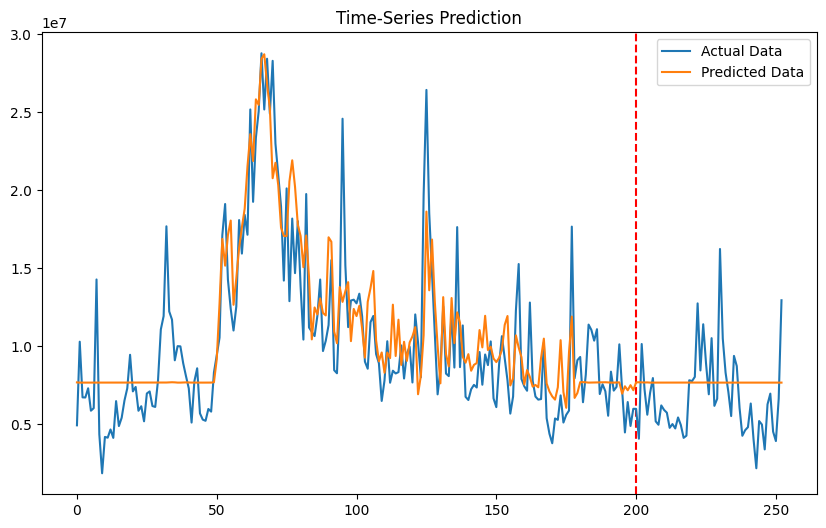

In [40]:
train_predict = model(df_x_ss)
predicted = train_predict.data.numpy()
label_y = df_y_ms.data.numpy()

predicted = ms.inverse_transform(predicted)
label_y = ms.inverse_transform(label_y)
plt.figure(figsize=(10, 6))
plt.axvline(x=200, c='r', linestyle='--')

plt.plot(label_y, label='Actual Data')
plt.plot(predicted, label='Predicted Data')
plt.title('Time-Series Prediction')
plt.legend()
plt.show()

1. axvline()은 그래프의 축을 따라 수직선을 표현할 때 사용하며 파라미터는 다음과 같다.
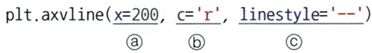

- a. 첫번째 파라미터: 어떤 지점에 수직선을 표현할지 지정한다.
- b. c: 어떤 색상으로 수직선을 표현할지 지정한다.
- c. linestyle: 어떤 스타일로 수직선을 표현할지 지정한다. 참고로 수평선은 axhline()을 사용하며 다음 그림과 같이 표현할 때 사용한다.

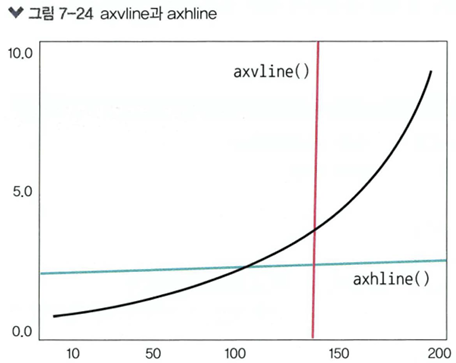

파란색은 실제 레이블에 대한 출력 결과이고 주황색은 모델이 예측한 결과를 보여 준다. 예측 결과가 만족스럽지 않다. 추후 GRU에 대해서도 동일한 데이터셋을 사용해볼 텐데 결과를 비교할 것이다. 이와같이 결과가 만족스럽지 않다면 하이퍼파라미터에 대한 튜닝도 중요하지만 모델을 변경해보는 것이 좋다.